In [1]:
import cv2
import os
import gc
import numpy as np
import pandas as pd
import time

from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              mean_squared_error, mean_absolute_error,
                              log_loss, r2_score)
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy as scipy_entropy

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All imports OK")
print("TensorFlow:", tf.__version__)

C:\Users\KIIT0001\miniconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
C:\Users\KIIT0001\miniconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


All imports OK
TensorFlow: 2.20.0


In [2]:
efficientnet = EfficientNetB0(
    weights     = "imagenet",
    include_top = False,
    pooling     = "avg"
)
efficientnet.trainable = False
print("EfficientNetB0 loaded — output:", efficientnet.output_shape)

EfficientNetB0 loaded — output: (None, 1280)


In [3]:
def extract_deep_features_from_paths(valid_paths, batch_size=32):
    """Extract EfficientNetB0 features in batches from file paths. Never stores
    more than batch_size images in RAM at once — prevents memory crashes."""
    all_features = []
    for i in tqdm(range(0, len(valid_paths), batch_size),
                  desc="  Deep features (batches)"):
        batch_paths = valid_paths[i : i + batch_size]
        batch_array = []
        for path in batch_paths:
            img = cv2.imread(path)
            if img is None:
                batch_array.append(np.zeros((224,224,3), dtype=np.float32))
                continue
            img_rgb = cv2.cvtColor(cv2.resize(img,(224,224)), cv2.COLOR_BGR2RGB)
            img_pre = preprocess_input(img_to_array(img_rgb))
            batch_array.append(img_pre)
            del img, img_rgb, img_pre
        batch_np = np.array(batch_array, dtype=np.float32)
        features = efficientnet.predict(batch_np, verbose=0)
        all_features.extend(features)
        del batch_array, batch_np, features
        gc.collect()
    return np.array(all_features, dtype=np.float32)

In [4]:
def extract_handcrafted_features(img):
    img = cv2.resize(img, (256, 256))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    H_ch, S_ch, V_ch = cv2.split(hsv)

    # Segmentation: saturation OR value thresholding handles pale backgrounds
    _, mask_s = cv2.threshold(S_ch, 25, 255, cv2.THRESH_BINARY)
    _, mask_v = cv2.threshold(V_ch, 40, 255, cv2.THRESH_BINARY)
    mask   = cv2.bitwise_or(mask_s, mask_v)
    kernel = np.ones((7,7), np.uint8)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return None
    cnt = max(contours, key=cv2.contourArea)
    if cv2.contourArea(cnt) < 256*256*0.01:
        return None

    area        = cv2.contourArea(cnt)
    perimeter   = cv2.arcLength(cnt, True)
    circularity = (4*np.pi*area) / (perimeter**2 + 1e-6)
    hull        = cv2.convexHull(cnt)
    solidity    = area / (cv2.contourArea(hull) + 1e-6)
    x,y,w,h     = cv2.boundingRect(cnt)
    aspect_ratio = w / (h + 1e-6)
    extent       = area / (w*h + 1e-6)

    R,G,B = cv2.split(img)
    R_mean,R_std = cv2.meanStdDev(R, mask=mask)
    G_mean,G_std = cv2.meanStdDev(G, mask=mask)
    B_mean,B_std = cv2.meanStdDev(B, mask=mask)

    H_mean,H_std = cv2.meanStdDev(H_ch, mask=mask)
    S_mean,S_std = cv2.meanStdDev(S_ch, mask=mask)
    V_mean,V_std = cv2.meanStdDev(V_ch, mask=mask)

    lab      = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    L,A,Bl   = cv2.split(lab)
    L_mean,L_std = cv2.meanStdDev(L,  mask=mask)
    a_mean,a_std = cv2.meanStdDev(A,  mask=mask)
    b_mean,b_std = cv2.meanStdDev(Bl, mask=mask)

    gray        = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_masked = cv2.bitwise_and(gray, gray, mask=mask)
    laplacian_variance = cv2.Laplacian(gray_masked, cv2.CV_64F).var()

    gray_small       = cv2.resize(gray_masked, (64,64))
    glcm             = graycomatrix(gray_small,[1],[0],256,symmetric=True,normed=True)
    glcm_contrast    = graycoprops(glcm,'contrast')[0,0]
    glcm_energy      = graycoprops(glcm,'energy')[0,0]
    glcm_homogeneity = graycoprops(glcm,'homogeneity')[0,0]

    hist              = cv2.calcHist([gray_masked],[0],mask,[256],[0,256])
    hist_norm         = hist / (hist.sum() + 1e-6)
    grayscale_entropy = scipy_entropy(hist_norm.flatten())

    total_pixels     = float(np.sum(mask > 0) + 1e-6)
    dark_pixel_ratio = np.sum(gray_masked < 50) / total_pixels

    return [
        float(R_mean[0][0]), float(G_mean[0][0]), float(B_mean[0][0]),
        float(R_std[0][0]),  float(G_std[0][0]),  float(B_std[0][0]),
        float(H_mean[0][0]), float(S_mean[0][0]), float(V_mean[0][0]),
        float(H_std[0][0]),  float(S_std[0][0]),  float(V_std[0][0]),
        float(L_mean[0][0]), float(L_std[0][0]),
        float(a_mean[0][0]), float(a_std[0][0]),
        float(b_mean[0][0]), float(b_std[0][0]),
        float(laplacian_variance),
        float(glcm_contrast), float(glcm_energy),
        float(glcm_homogeneity), float(grayscale_entropy),
        float(area), float(perimeter),
        float(circularity), float(solidity),
        float(aspect_ratio), float(extent),
        float(dark_pixel_ratio)
    ]

In [5]:
def detect_fruit_category_from_image(img_path, available_categories):
    img = cv2.imread(img_path)
    if img is None:
        return "_global"

    img_resized = cv2.resize(img, (128, 128))
    hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)

    # Segment out background (white/very pale)
    _, mask_s = cv2.threshold(S, 25, 255, cv2.THRESH_BINARY)
    _, mask_v = cv2.threshold(V, 40, 255, cv2.THRESH_BINARY)
    mask = cv2.bitwise_or(mask_s, mask_v)

    del img

    # Get hue values of fruit pixels only
    hue_vals = H[mask > 0].astype(np.float32)
    if len(hue_vals) < 100:
        return "_global"

    total = float(len(hue_vals))

    # ── Count pixels in each hue range ────────────────────────────────
    # Red    : H=0-15  OR  H=160-180  (wraps around in OpenCV 0-180)
    red_frac    = (np.sum(hue_vals <= 15) + np.sum(hue_vals >= 160)) / total
    # Yellow  : H=16-35
    yellow_frac = np.sum((hue_vals > 15) & (hue_vals <= 35)) / total
    # Green   : H=36-85
    green_frac  = np.sum((hue_vals > 35) & (hue_vals <= 85)) / total
    # Cyan-blue (not really fruit but catches segmentation errors)
    # Brown/neutral: H=10-25 with LOW saturation
    sat_vals    = S[mask > 0].astype(np.float32)
    low_sat     = float(np.mean(sat_vals < 60))   # fraction of low-sat pixels
    mean_sat    = float(np.mean(sat_vals))

    # ── Shape: aspect ratio from bounding box ─────────────────────────
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    aspect_ratio = 1.0
    if contours:
        cnt = max(contours, key=cv2.contourArea)
        x,y,w,h = cv2.boundingRect(cnt)
        aspect_ratio = w / (h + 1e-6)

    # ── Decision logic ─────────────────────────────────────────────────
    cats = set(available_categories)

    # Potato: pale/brown (low saturation, yellowish hue)
    if low_sat > 0.55 and mean_sat < 70 and "potato" in cats:
        return "potato"

    # Green fruits: cucumber
    if green_frac > 0.35 and "cucumber" in cats:
        return "cucumber"

    # Yellow fruits: banana (also elongated)
    if yellow_frac > 0.30 and "banana" in cats:
        return "banana"

    # Red fruits: apple or capsicum
    if red_frac > 0.30:
        # Capsicum tends to be more round and has a more uniform red
        # Apple tends to be round with slight yellow tones
        if "capsicum" in cats and "apple" in cats:
            # Use saturation: capsicum is typically brighter red (higher sat)
            if mean_sat > 130:
                return "capsicum"
            else:
                return "apple"
        if "capsicum" in cats:
            return "capsicum"
        if "apple" in cats:
            return "apple"

    # Fallback: pick by dominant hue fraction
    scores = {}
    if "apple"    in cats: scores["apple"]    = red_frac
    if "capsicum" in cats: scores["capsicum"] = red_frac
    if "banana"   in cats: scores["banana"]   = yellow_frac
    if "cucumber" in cats: scores["cucumber"] = green_frac
    if "potato"   in cats: scores["potato"]   = low_sat * 0.5

    if scores:
        best = max(scores, key=scores.get)
        # If capsicum and apple both score same, use shape
        if "capsicum" in scores and "apple" in scores:
            if scores["capsicum"] == scores["apple"]:
                best = "capsicum" if aspect_ratio < 1.2 else "apple"
        return best

    return "_global"


In [6]:
dataset_path = r"C:\Users\KIIT0001\Desktop\Final_Grade\archive(8)\vegetable_Dataset"

start_time = time.time()

print("Scanning dataset folder...")
all_paths, all_labels, all_subfolders = [], [], []

for category in ["Fresh", "Rotten"]:
    cat_path = os.path.join(dataset_path, category)
    if not os.path.isdir(cat_path):
        print(f"WARNING: not found: {cat_path}")
        continue
    for subfolder in os.listdir(cat_path):
        sub_path = os.path.join(cat_path, subfolder)
        if not os.path.isdir(sub_path):
            continue
        for file in os.listdir(sub_path):
            if not file.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp')):
                continue
            all_paths.append(os.path.join(sub_path, file))
            all_labels.append(category)
            all_subfolders.append(subfolder.lower())

print(f"Total : {len(all_paths)}  |  Fresh: {all_labels.count('Fresh')}  |  Rotten: {all_labels.count('Rotten')}")
print(f"Subfolders: {sorted(set(all_subfolders))}")

# Handcrafted features
print("\nExtracting handcrafted features...")
X_hand, valid_paths, labels, subfolders = [], [], [], []
t1 = time.time()

for path, label, sf in tqdm(zip(all_paths, all_labels, all_subfolders),
                             total=len(all_paths), desc="  Handcrafted"):
    img = cv2.imread(path)
    if img is None:
        continue
    hand = extract_handcrafted_features(img)
    del img
    gc.collect()
    if hand is None:
        continue
    X_hand.append(hand)
    valid_paths.append(path)
    labels.append(label)
    subfolders.append(sf)

print(f"Handcrafted done: {len(X_hand)} images  |  {time.time()-t1:.1f}s")

# Deep features in batches
print("\nExtracting deep features in batches of 32...")
t2 = time.time()
X_deep = extract_deep_features_from_paths(valid_paths, batch_size=32)
print(f"Deep features done  |  {time.time()-t2:.1f}s")
print(f"Total: {time.time()-start_time:.1f}s")

Scanning dataset folder...
Total : 13232  |  Fresh: 6076  |  Rotten: 7156
Subfolders: ['freshapple', 'freshbanana', 'freshcapciscum', 'freshcucumber', 'freshpotato', 'rottenapple', 'rottenbanana', 'rottencapsicum', 'rottencucumber', 'rottenpotato']

Extracting handcrafted features...


  Handcrafted: 100%|███████████████████████████████████████████████████████████| 13232/13232 [1:36:56<00:00,  2.27it/s]


Handcrafted done: 13232 images  |  5816.7s

Extracting deep features in batches of 32...


  Deep features (batches): 100%|█████████████████████████████████████████████████████| 414/414 [31:51<00:00,  4.62s/it]

Deep features done  |  1912.1s
Total: 7730.3s


In [7]:
X_hand     = np.array(X_hand, dtype=np.float32)
y_raw      = np.array(labels)
subfolders = np.array(subfolders)

print("Handcrafted:", X_hand.shape)
print("Deep       :", X_deep.shape)

Handcrafted: (13232, 30)
Deep       : (13232, 1280)


In [8]:
n_components = min(100, X_deep.shape[1], X_deep.shape[0]-1)
pca          = PCA(n_components=n_components, random_state=42)
X_deep_pca   = pca.fit_transform(X_deep)
print("PCA:", X_deep.shape, "→", X_deep_pca.shape)
print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

PCA: (13232, 1280) → (13232, 100)
Variance explained: 79.77%


In [9]:
X_fused = np.hstack((X_hand, X_deep_pca))
print("Fused shape:", X_fused.shape)

Fused shape: (13232, 130)


In [10]:
le = LabelEncoder()
y  = le.fit_transform(y_raw)
print("Classes:", le.classes_)

Classes: ['Fresh' 'Rotten']


In [11]:
X_hand_raw = X_hand.copy()
scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(X_fused)
print("Done. X_scaled:", X_scaled.shape)

Done. X_scaled: (13232, 130)


In [12]:
category_reference_vectors = {}

unique_fresh_subfolders = sorted(set(
    sf for sf, lbl in zip(subfolders, y_raw) if lbl == "Fresh"
))

print("Building reference vectors from Fresh samples:\n")
for sf in unique_fresh_subfolders:
    mask_sf = (subfolders == sf) & (y_raw == "Fresh")
    if mask_sf.sum() == 0:
        continue
    ref_vec = X_hand_raw[mask_sf].mean(axis=0)
    base    = sf.replace("fresh","").strip()
    category_reference_vectors[base] = ref_vec
    print(f"  {sf:<28} → '{base}'  ({mask_sf.sum()} images)")

# Global fallback
global_fresh_mask = (y_raw == "Fresh")
category_reference_vectors["_global"] = X_hand_raw[global_fresh_mask].mean(axis=0)

print(f"\nCategories: {[k for k in category_reference_vectors if k != '_global']}")

# Available categories list for the detector
available_categories = [k for k in category_reference_vectors.keys() if k != "_global"]

Building reference vectors from Fresh samples:

  freshapple                   → 'apple'  (1949 images)
  freshbanana                  → 'banana'  (2105 images)
  freshcapciscum               → 'capciscum'  (933 images)
  freshcucumber                → 'cucumber'  (435 images)
  freshpotato                  → 'potato'  (654 images)

Categories: ['apple', 'banana', 'capciscum', 'cucumber', 'potato']


In [13]:
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

# Train final SVM on all data (used at test time)
print("Training final SVM on full dataset...")
svm_final = SVC(kernel="rbf", C=10.0, gamma="scale", probability=True, random_state=42)
svm_final.fit(X_scaled, y)
print("Final SVM ready\n")

print("5-Fold Cross-Validation:\n")
for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    svm_cv = SVC(kernel="rbf", C=10.0, gamma="scale", probability=True, random_state=42)
    svm_cv.fit(X_train, y_train)

    y_pred = svm_cv.predict(X_test)
    y_prob = svm_cv.predict_proba(X_test)[:,1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    ll   = log_loss(y_test, y_prob)

    results.append([fold, round(acc*100,2), round(prec*100,2), round(rec*100,2),
                    round(f1*100,2), round(mse,4), round(rmse,4), round(mae,4),
                    round(ll,4), round(r2,4)])
    print(f"  Fold {fold}  Acc={acc*100:.2f}%  Prec={prec*100:.2f}%  "
          f"Rec={rec*100:.2f}%  F1={f1*100:.2f}%")

Training final SVM on full dataset...
Final SVM ready

5-Fold Cross-Validation:

  Fold 1  Acc=99.02%  Prec=99.02%  Rec=99.16%  F1=99.09%
  Fold 2  Acc=99.28%  Prec=99.30%  Rec=99.37%  F1=99.34%
  Fold 3  Acc=98.37%  Prec=98.06%  Rec=98.95%  F1=98.50%
  Fold 4  Acc=99.21%  Prec=99.44%  Rec=99.09%  F1=99.26%
  Fold 5  Acc=99.17%  Prec=98.69%  Rec=99.79%  F1=99.24%


In [14]:
# ── Fruit / Vegetable Type Classifier ───────────────────────────────
# Trains a dedicated SVM to identify WHAT fruit/vegetable is in the image.
# Uses the same EfficientNetB0 deep features (X_deep_pca) already computed.
# Labels come from your dataset subfolder names (e.g. freshapple → apple).

# Step 1: Build type labels from subfolder names
#         Strip 'fresh'/'rotten' prefix → get base fruit name
type_labels = np.array([
    sf.replace("fresh","").replace("rotten","").strip()
    for sf in subfolders
])

# Step 2: Encode type labels
type_le = LabelEncoder()
y_type  = type_le.fit_transform(type_labels)

print("Fruit/Vegetable types found in dataset:")
for i, cls in enumerate(type_le.classes_):
    count = int(np.sum(y_type == i))
    print(f"  {cls:<20} : {count} images")

# Step 3: Train type SVM on deep PCA features
#         Uses only deep features — they capture visual appearance best
type_scaler = StandardScaler()
X_type      = type_scaler.fit_transform(X_deep_pca)

type_svm = SVC(kernel="rbf", C=10.0, gamma="scale",
               probability=True, random_state=42)
type_svm.fit(X_type, y_type)

print(f"\nType classifier trained on {len(y_type)} images")
print(f"Classes: {list(type_le.classes_)}")


Fruit/Vegetable types found in dataset:
  apple                : 4459 images
  banana               : 4701 images
  capciscum            : 933 images
  capsicum             : 812 images
  cucumber             : 891 images
  potato               : 1436 images

Type classifier trained on 13232 images
Classes: [np.str_('apple'), np.str_('banana'), np.str_('capciscum'), np.str_('capsicum'), np.str_('cucumber'), np.str_('potato')]


In [15]:
results_df = pd.DataFrame(results, columns=[
    "Fold","Accuracy","Precision","Recall","F1",
    "MSE","RMSE","MAE","LogLoss","R2"
])
print("="*80)
print(results_df.to_string(index=False))
print("="*80)
print("\n── Average Metrics ──")
for col,val in results_df.iloc[:,1:].mean().items():
    print(f"  {col:<12}: {val:.4f}")
print(f"\nTotal time: {time.time()-start_time:.1f}s")

 Fold  Accuracy  Precision  Recall    F1    MSE   RMSE    MAE  LogLoss     R2
    1     99.02      99.02   99.16 99.09 0.0098 0.0991 0.0098   0.0373 0.9604
    2     99.28      99.30   99.37 99.34 0.0072 0.0847 0.0072   0.0214 0.9711
    3     98.37      98.06   98.95 98.50 0.0163 0.1275 0.0163   0.0472 0.9346
    4     99.21      99.44   99.09 99.26 0.0079 0.0891 0.0079   0.0243 0.9680
    5     99.17      98.69   99.79 99.24 0.0083 0.0912 0.0083   0.0290 0.9665

── Average Metrics ──
  Accuracy    : 99.0100
  Precision   : 98.9020
  Recall      : 99.2720
  F1          : 99.0860
  MSE         : 0.0099
  RMSE        : 0.0983
  MAE         : 0.0099
  LogLoss     : 0.0318
  R2          : 0.9601

Total time: 8076.3s


In [16]:
def compute_freshness_score(hand_features, deep_features_pca, reference_vector):

    ref  = np.array(reference_vector, dtype=np.float64)
    feat = np.array(hand_features,    dtype=np.float64)

    def _norm_dev(indices):
        idx  = list(indices)
        diff = np.abs(feat[idx] - ref[idx])
        norm = diff / (np.abs(ref[idx]) + 1e-6)
        return float(np.clip(np.mean(norm), 0.0, 1.0))

    # Degradation indicators
    C = _norm_dev([12, 13, 14, 15, 16, 17])   # LAB color deviation
    T = _norm_dev([19, 20, 21, 22])             # Texture roughness
    D = float(np.clip(feat[29], 0.0, 1.0))     # Dark pixel ratio
    S = _norm_dev([25, 26, 27, 28])             # Shape distortion

    DI           = float(np.clip(0.25*C + 0.20*T + 0.40*D + 0.15*S, 0.0, 1.0))
    freshness_di = float(np.clip((1.0 - DI) * 100.0, 0.0, 100.0))

    # SVM probability
    fused_feat     = np.hstack((hand_features, deep_features_pca)).reshape(1, -1)
    fused_scaled   = scaler.transform(fused_feat)
    svm_prob       = svm_final.predict_proba(fused_scaled)[0]
    fresh_lbl      = int(le.transform(["Fresh"])[0])
    svm_fresh_prob = float(svm_prob[fresh_lbl])
    svm_freshness  = svm_fresh_prob * 100.0

    # Blend DI + SVM
    if svm_fresh_prob >= 0.85:
        freshness = 0.30 * freshness_di + 0.70 * svm_freshness
    elif svm_fresh_prob <= 0.15:
        freshness = 0.30 * freshness_di + 0.70 * svm_freshness
    else:
        freshness = 0.55 * freshness_di + 0.45 * svm_freshness

    freshness = float(np.clip(freshness, 0.0, 100.0))

    # ── 4-Grade system ────────────────────────────────────────────────
    if freshness > 80:
       grade        = "Very Fresh"
       grade_colour = "#2e7d32"
       grade_emoji  = "🟢"
    elif freshness > 60:
       grade        = "Fresh"
       grade_colour = "#8bc34a"
       grade_emoji  = "🟡"
    elif freshness > 40:
       grade        = "Moderate"
       grade_colour = "#ff9800"
       grade_emoji  = "🟠"
    elif freshness > 20:
       grade        = "Slightly Rotten"
       grade_colour = "#e64a19"
       grade_emoji  = "🟤"
    else:
       grade        = "Rotten"
       grade_colour = "#c62828"
       grade_emoji  = "🔴"

    return {
        "freshness"     : round(freshness, 2),
        "grade"         : grade,
        "grade_colour"  : grade_colour,
        "grade_emoji"   : grade_emoji,
        "DI"            : round(DI, 4),
        "C"             : round(C,  4),
        "T"             : round(T,  4),
        "D"             : round(D,  4),
        "S"             : round(S,  4),
        "svm_prob"      : round(svm_fresh_prob, 3)
    }

In [17]:
def test_multiple_images(folder_path, category_reference_vectors,
                         available_categories, batch_size=32):
    """
    Run hybrid freshness grading on all images in a folder.
    - Memory safe: images loaded in batches from disk
    - Category detected from actual pixel hue — NOT reference vector comparison
    - 4-grade output: Very Fresh / Fresh / Moderate / Rotten
    """
    valid_ext   = ('.jpg','.jpeg','.png','.bmp','.webp')
    image_files = sorted([f for f in os.listdir(folder_path)
                          if f.lower().endswith(valid_ext)])

    if not image_files:
        print("No images found in:", folder_path)
        return

    # Phase 1: Handcrafted features
    print("Extracting handcrafted features...")
    test_paths, test_hand, test_names = [], [], []

    for img_name in tqdm(image_files, desc="  Handcrafted"):
        img_path = os.path.join(folder_path, img_name)
        img      = cv2.imread(img_path)
        if img is None:
            print(f"  Cannot read: {img_name}")
            continue
        hand = extract_handcrafted_features(img)
        del img
        if hand is None:
            print(f"  No fruit detected: {img_name} — skipped")
            continue
        test_paths.append(img_path)
        test_hand.append(np.array(hand, dtype=np.float32))
        test_names.append(img_name)

    if not test_paths:
        print("No valid images.")
        return

    # Phase 2: Deep features in batches
    print("\nExtracting deep features...")
    test_deep_all = extract_deep_features_from_paths(test_paths, batch_size=batch_size)
    test_deep_pca = pca.transform(test_deep_all)

    # Phase 3: Score + display
    print("\nResults:\n")

    for img_name, img_path, hand, deep_pca in zip(test_names, test_paths,
                                                   test_hand, test_deep_pca):
        img     = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        del img

        # ── Category from PIXEL COLORS (not reference comparison) ─────
        detected_cat = detect_fruit_category_from_image(img_path, available_categories)
        ref_vec      = category_reference_vectors.get(
                           detected_cat, category_reference_vectors["_global"])

        # ── Fruit / Vegetable type via trained SVM ── (NEW) ───────────
        deep_scaled   = type_scaler.transform(deep_pca.reshape(1, -1))
        type_pred_idx = type_svm.predict(deep_scaled)[0]
        fruit_name    = type_le.classes_[type_pred_idx].title()

        # ── Hybrid freshness score ─────────────────────────────────────
        result       = compute_freshness_score(hand, deep_pca, ref_vec)
        freshness    = result["freshness"]
        grade        = result["grade"]
        colour       = result["grade_colour"]
        emoji        = result["grade_emoji"]
        DI           = result["DI"]
        C,T,D,S      = result["C"], result["T"], result["D"], result["S"]
        svm_prob     = result["svm_prob"]

        # ── Display ───────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(4.5, 5.8))
        ax.imshow(img_rgb)
        ax.axis("off")

        ax.set_title(
            f"{img_name}\n"
            f"Freshness: {freshness}%",
            fontsize=9, fontweight="bold", pad=6
        )

        # ── Fruit/Vegetable name from SVM ── (NEW — one line added) ───
        ax.text(0.5, -0.02,
                f"Type: {fruit_name}",
                transform=ax.transAxes, ha="center", va="top",
                fontsize=11, fontweight="bold", color="#1a237e")

        ax.text(0.5, -0.09,
                f"{emoji}  Grade: {grade}",
                transform=ax.transAxes, ha="center", va="top",
                fontsize=13, fontweight="bold", color=colour)

        ax.text(0.5, -0.16,
                f"DI={DI}   C={C}   T={T}   D={D}   S={S}",
                transform=ax.transAxes, ha="center", va="top",
                fontsize=7, color="dimgray")

        ax.text(0.5, -0.21,
                f"SVM fresh confidence: {svm_prob:.1%}",
                transform=ax.transAxes, ha="center", va="top",
                fontsize=7, color="gray")

        # Freshness bar with grade zone markers
        bar = fig.add_axes([0.1, 0.005, 0.8, 0.025])
        # Background zones (Rotten / Moderate / Fresh / Very Fresh)
        bar.barh(0, 0.40, color="#ffcdd2", height=1)
        bar.barh(0, 0.20, left=0.40, color="#ffe0b2", height=1)
        bar.barh(0, 0.20, left=0.60, color="#dcedc8", height=1)
        bar.barh(0, 0.20, left=0.80, color="#c8e6c9", height=1)
        # Freshness indicator
        bar.axvline(x=freshness/100, color="black", linewidth=2)
        bar.set_xlim(0, 1)
        bar.axis("off")
        bar.text(0.10, 2.0, "Rotten",          fontsize=5, ha="center", color="#c62828")
        bar.text(0.30, 2.0, "Slightly Rotten", fontsize=5, ha="center", color="#e64a19")
        bar.text(0.50, 2.0, "Moderate",        fontsize=5, ha="center", color="#ff9800")
        bar.text(0.70, 2.0, "Fresh",           fontsize=5, ha="center", color="#558b2f")
        bar.text(0.90, 2.0, "Very Fresh",      fontsize=5, ha="center", color="#2e7d32")

        plt.tight_layout()
        plt.show()

        del img_rgb
        gc.collect()

    print(f"\nDone. {len(test_names)} images processed.")


Extracting handcrafted features...


  Handcrafted: 100%|█████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 20.41it/s]



Extracting deep features...


  Deep features (batches): 100%|█████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.51s/it]



Results:



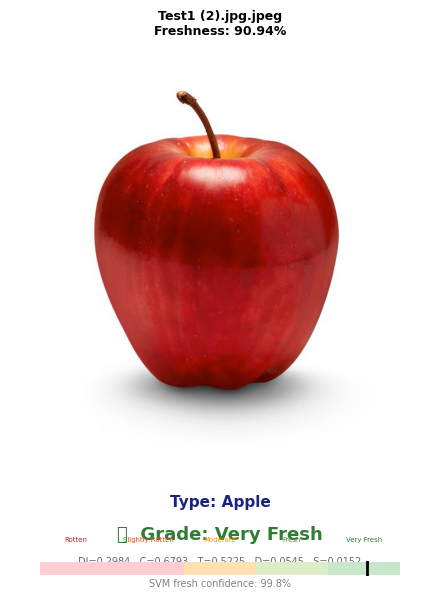

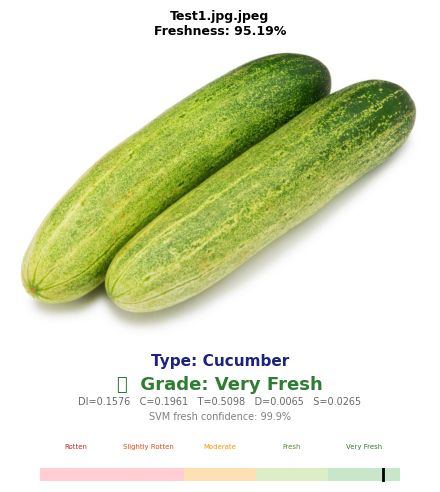

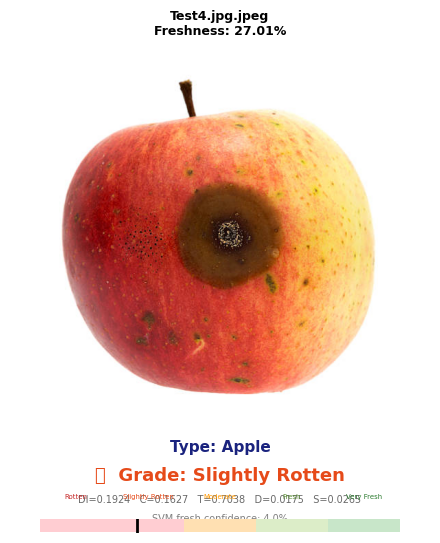

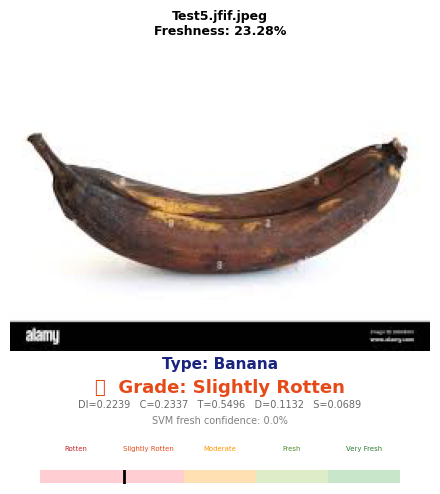

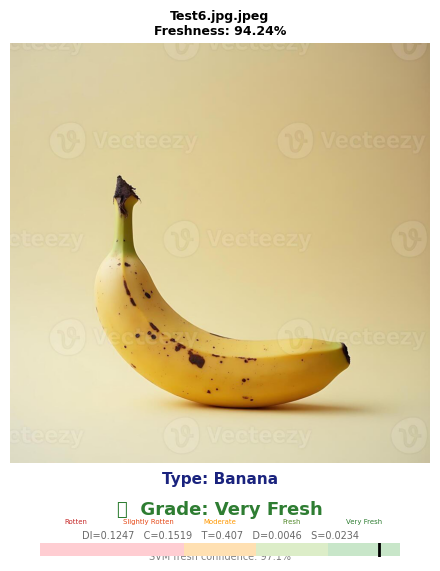

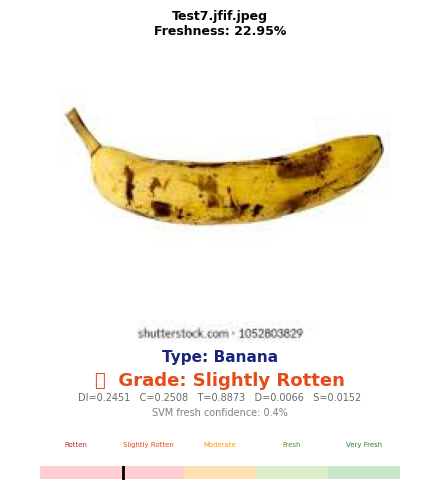

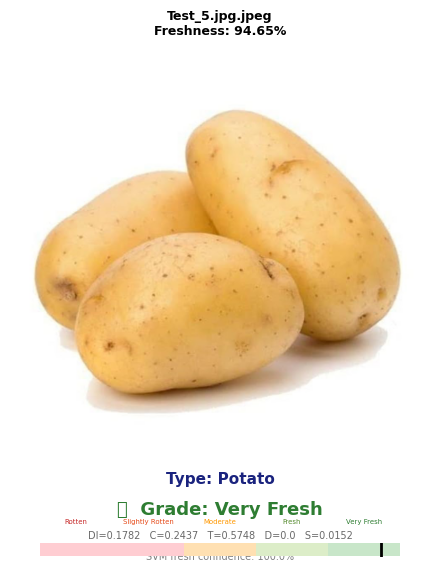

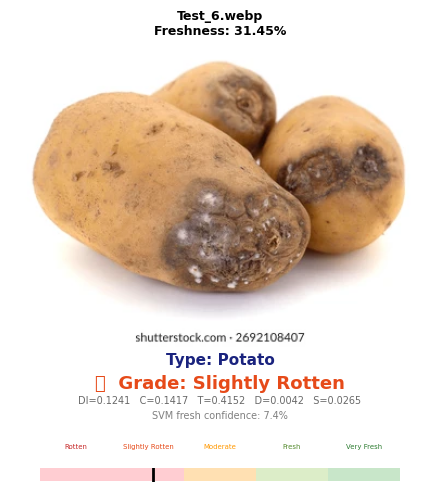

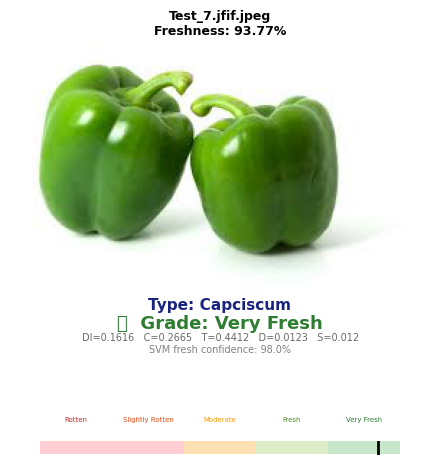


Done. 9 images processed.


In [18]:
folder_path = r"C:\Users\KIIT0001\Desktop\Final_Grade\Image"

test_multiple_images(
    folder_path,
    category_reference_vectors,
    available_categories,
    batch_size=32
)